# Fisrt visit WGAN_GP . I explain that in detail. I skip some part here.

# Data extraction from .tar file

In [1]:
# =======================
# 1. Extract BRATS Data
# =======================
import tarfile
import os

source_path = "/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_Training_Data.tar"
extract_path = "/kaggle/working/brats2021"

os.makedirs(extract_path, exist_ok=True)

with tarfile.open(source_path) as tar:
    tar.extractall(path=extract_path)

print("Extraction complete!")

/tmp/ipykernel_55/2752476768.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


Extraction complete!


# Preprocess same as WGAN-GP. But filterning is slightly less than WGAN and DCGAN. We need more images for CGAN. since we are going to divided in two label. Small tumor and Large tumor images

In [2]:
# ============================
# 1️⃣ Imports
# ============================
import os
import nibabel as nib
import numpy as np
import cv2
from tqdm import tqdm

IMG_SIZE = 128

extract_path = "/kaggle/working/brats2021"

input_images = []
tumor_sizes = []

# ============================
# 2️⃣ Normalize Function
# ============================
def normalize(img):
    img = img.astype(np.float32)
    img = (img - np.mean(img)) / (np.std(img)+1e-8)
    img = (img - img.min())/(img.max()-img.min()+1e-8)
    return img * 2 - 1

# ============================
# 3️⃣ Load ALL Patients
# ============================
patient_folders = sorted([
    f for f in os.listdir(extract_path)
    if os.path.isdir(os.path.join(extract_path, f)) and "BraTS" in f
])

print("Total patients:", len(patient_folders))

# ============================
# 4️⃣ Process Data
# ============================
for patient in tqdm(patient_folders):
    ppath = os.path.join(extract_path, patient)
    files = os.listdir(ppath)

    flair_path = [f for f in files if "flair" in f][0]
    seg_path   = [f for f in files if "seg" in f][0]

    flair_img = nib.load(os.path.join(ppath, flair_path)).get_fdata()
    seg_img   = nib.load(os.path.join(ppath, seg_path)).get_fdata()

    # Use middle slices only (avoid empty top/bottom)
    start = int(flair_img.shape[2] * 0.2)
    end   = int(flair_img.shape[2] * 0.8)

    for i in range(start, end):
        slice_img = flair_img[:, :, i]
        slice_seg = seg_img[:, :, i]

        # ------------------------
        # ❌ Remove empty slices
        # ------------------------
        if np.sum(slice_img > 0) < 500:
            continue

        # ------------------------
        # ❌ Remove very small tumor
        # ------------------------
        tumor_area = np.sum(slice_seg > 0)
        if tumor_area < 300:   # threshold (tune if needed)
            continue

        # ------------------------
        # Crop brain region
        # ------------------------
        coords = np.argwhere(slice_img > np.percentile(slice_img, 5))
        if coords.shape[0] == 0:
            continue

        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)

        pad = 10
        y_min = max(0, y_min - pad)
        x_min = max(0, x_min - pad)
        y_max = min(slice_img.shape[0], y_max + pad)
        x_max = min(slice_img.shape[1], x_max + pad)

        crop_img = slice_img[y_min:y_max, x_min:x_max]
        crop_seg = slice_seg[y_min:y_max, x_min:x_max]

        # ------------------------
        # Resize
        # ------------------------
        img = cv2.resize(crop_img, (IMG_SIZE, IMG_SIZE))
        segm = cv2.resize(crop_seg, (IMG_SIZE, IMG_SIZE))

        # ------------------------
        # Normalize
        # ------------------------
        img = normalize(img)

        input_images.append(img[..., None])
        tumor_sizes.append(np.sum(segm > 0))

# Convert to numpy
input_images = np.array(input_images, dtype="float32")
tumor_sizes = np.array(tumor_sizes)

print("Final dataset shape:", input_images.shape)

Total patients: 1251


100%|██████████| 1251/1251 [05:57<00:00,  3.50it/s]


Final dataset shape: (64148, 128, 128, 1)


# Based on Median tumor value we split in two class. Each has 32k image. and DCGAN and WGAN has 41k. We try to balance as much as possible. But each GAN is different so necessary changes must take place.

In [3]:
# ============================
# 1️⃣ Define Threshold
# ============================
# Use median tumor size as threshold
threshold = np.median(tumor_sizes)

# ============================
# 2️⃣ Split Dataset
# ============================
small_indices = np.where(tumor_sizes < threshold)[0]
large_indices = np.where(tumor_sizes >= threshold)[0]

small_images = input_images[small_indices]
large_images = input_images[large_indices]

# ============================
# 3️⃣ Print Counts
# ============================
print("Total Images:", len(input_images))
print("Small Tumor Images:", len(small_images))
print("Large Tumor Images:", len(large_images))

Total Images: 64148
Small Tumor Images: 32058
Large Tumor Images: 32090


# Some images of both classes

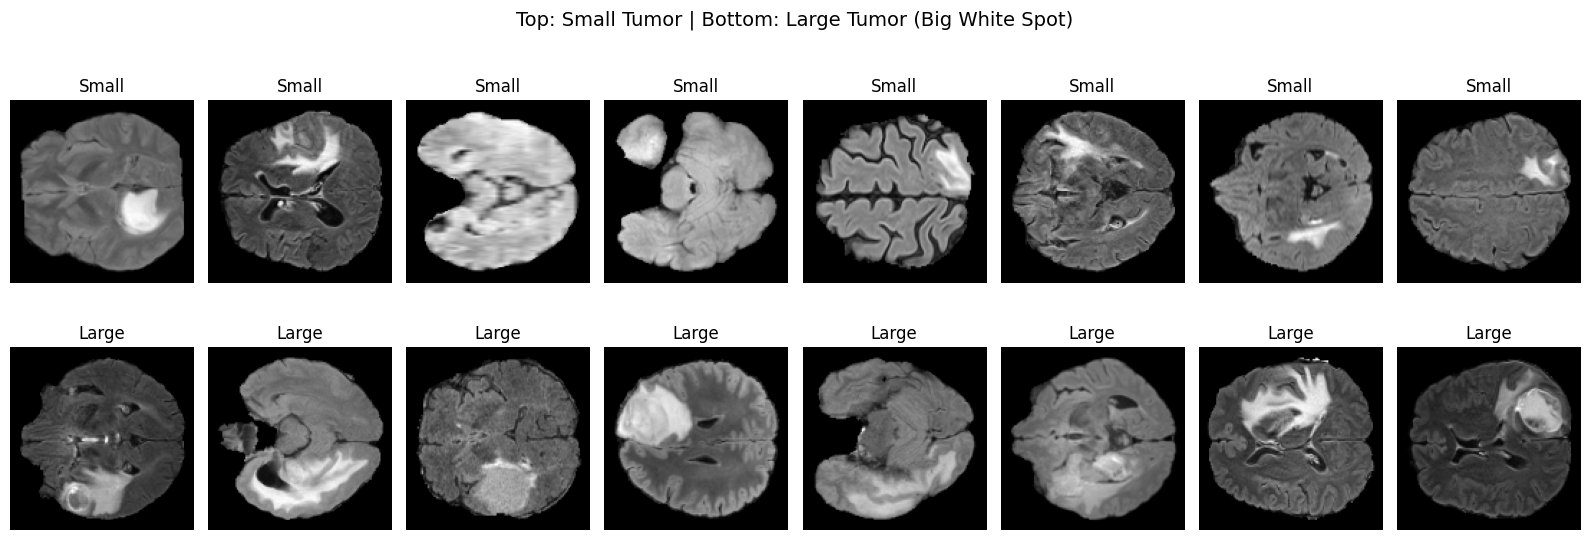

In [4]:
import matplotlib.pyplot as plt
import random

num_samples = 8

# Randomly pick samples
small_samples = random.sample(range(len(small_images)), num_samples)
large_samples = random.sample(range(len(large_images)), num_samples)

plt.figure(figsize=(16, 6))

# 🔹 Row 1: Small Tumors
for i, idx in enumerate(small_samples):
    img = (small_images[idx] + 1) / 2  # scale to [0,1]
    
    plt.subplot(2, num_samples, i+1)
    plt.imshow(img[:,:,0], cmap='gray')
    plt.title("Small")
    plt.axis('off')

# 🔹 Row 2: Large Tumors
for i, idx in enumerate(large_samples):
    img = (large_images[idx] + 1) / 2
    
    plt.subplot(2, num_samples, i+1+num_samples)
    plt.imshow(img[:,:,0], cmap='gray')
    plt.title("Large")
    plt.axis('off')

plt.suptitle("Top: Small Tumor | Bottom: Large Tumor (Big White Spot)", fontsize=14)
plt.tight_layout()
plt.show()

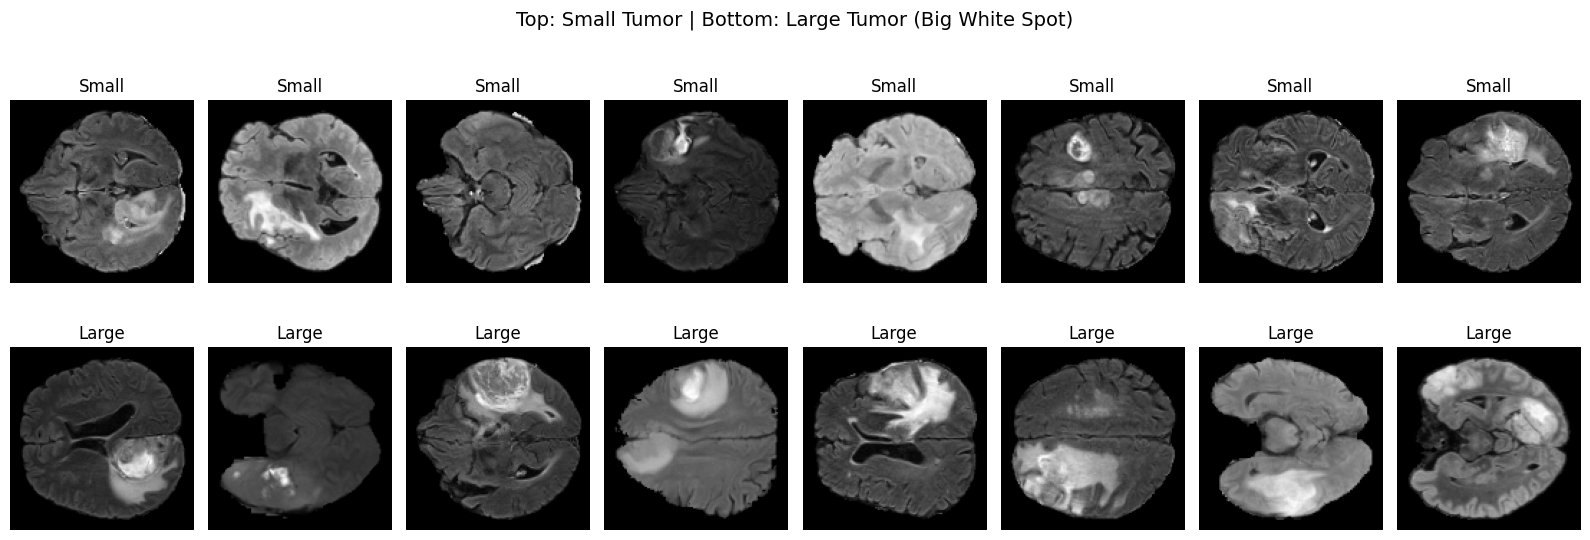

In [5]:
import matplotlib.pyplot as plt
import random

num_samples = 8

# Randomly pick samples
small_samples = random.sample(range(len(small_images)), num_samples)
large_samples = random.sample(range(len(large_images)), num_samples)

plt.figure(figsize=(16, 6))

# 🔹 Row 1: Small Tumors
for i, idx in enumerate(small_samples):
    img = (small_images[idx] + 1) / 2  # scale to [0,1]
    
    plt.subplot(2, num_samples, i+1)
    plt.imshow(img[:,:,0], cmap='gray')
    plt.title("Small")
    plt.axis('off')

# 🔹 Row 2: Large Tumors
for i, idx in enumerate(large_samples):
    img = (large_images[idx] + 1) / 2
    
    plt.subplot(2, num_samples, i+1+num_samples)
    plt.imshow(img[:,:,0], cmap='gray')
    plt.title("Large")
    plt.axis('off')

plt.suptitle("Top: Small Tumor | Bottom: Large Tumor (Big White Spot)", fontsize=14)
plt.tight_layout()
plt.show()

# Use concatenate to merge both class and apply one-hot encoder

In [6]:
import tensorflow as tf
import numpy as np
from IPython.display import clear_output


# Combine both datasets
input_images = np.concatenate([small_images, large_images], axis=0)

# Labels: 0 = small, 1 = large
labels_bin = np.array([0]*len(small_images) + [1]*len(large_images))

# Shuffle
idx = np.random.permutation(len(input_images))
input_images = input_images[idx]
labels_bin = labels_bin[idx]

# One-hot encode
labels_onehot = tf.one_hot(labels_bin, depth=2)

# Dataset
BATCH_SIZE = 32
dataset = tf.data.Dataset.from_tensor_slices((input_images, labels_onehot))
dataset = dataset.shuffle(5000).batch(BATCH_SIZE)

print("Final dataset:", input_images.shape)
print("Label count:", np.bincount(labels_bin))

2026-04-23 12:37:08.602862: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776947828.786852      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776947828.845645      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776947829.315438      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776947829.315471      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776947829.315474      55 computation_placer.cc:177] computation placer alr

Final dataset: (64148, 128, 128, 1)
Label count: [32058 32090]


# Generator same as WGAN-GP

In [7]:
from tensorflow.keras import layers

z_dim = 100
num_classes = 2
IMG_SIZE = 128

def build_generator():
    noise = layers.Input(shape=(z_dim,))
    label = layers.Input(shape=(num_classes,))
    
    x = layers.Concatenate()([noise, label])

    x = layers.Dense(8*8*512, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Reshape((8,8,512))(x)

    x = layers.Conv2DTranspose(256,4,2,'same',use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(128,4,2,'same',use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(64,4,2,'same',use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    out = layers.Conv2DTranspose(1,4,2,'same',activation='tanh')(x)

    return tf.keras.Model([noise,label], out)

generator = build_generator()

# Discriminator Same


In [8]:
def build_discriminator():
    img = layers.Input(shape=(IMG_SIZE,IMG_SIZE,1))
    label = layers.Input(shape=(IMG_SIZE,IMG_SIZE,2))

    x = layers.Concatenate()([img,label])

    x = layers.Conv2D(64,4,2,'same')(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(128,4,2,'same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(256,4,2,'same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(512,4,2,'same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    out = layers.Conv2D(1,4,1,'same')(x)

    return tf.keras.Model([img,label], out)

discriminator = build_discriminator()

# loss is BinaryCrossentropy
* learning rate G=1e-4,D=2e-4 and beta=0.5

In [9]:
bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def gen_loss(fake):
    return bce(tf.ones_like(fake), fake)

def disc_loss(real, fake):
    return bce(tf.ones_like(real), real) + bce(tf.zeros_like(fake), fake)

g_opt = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)
d_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

# Training step

In [10]:
@tf.function
def train_step(images, labels):
    batch = tf.shape(images)[0]
    noise = tf.random.normal([batch, z_dim])

    with tf.GradientTape() as gt, tf.GradientTape() as dt:
        fake = generator([noise, labels], training=True)

        label_map = tf.reshape(labels, [batch,1,1,2])
        label_map = tf.tile(label_map, [1,IMG_SIZE,IMG_SIZE,1])

        real_out = discriminator([images,label_map], training=True)
        fake_out = discriminator([fake,label_map], training=True)

        g_loss = gen_loss(fake_out)
        d_loss = disc_loss(real_out, fake_out)

    g_opt.apply_gradients(zip(gt.gradient(g_loss, generator.trainable_variables),
                              generator.trainable_variables))
    d_opt.apply_gradients(zip(dt.gradient(d_loss, discriminator.trainable_variables),
                              discriminator.trainable_variables))
    
    return g_loss, d_loss

In [11]:
import matplotlib.pyplot as plt

def generate_images(epoch):
    noise = tf.random.normal([2, z_dim])
    labels = tf.one_hot([0,1], depth=2)  # small vs large

    imgs = generator([noise, labels], training=False)
    imgs = (imgs+1)/2

    plt.figure(figsize=(6,3))
    for i in range(2):
        plt.subplot(1,2,i+1)
        plt.imshow(imgs[i,:,:,0], cmap='gray')
        plt.title("Small Tumor" if i==0 else "Large Tumor")
        plt.axis('off')
    plt.suptitle(f"Epoch {epoch}")
    plt.show()

# Training loop
# each epoch time 4 min 24 sec

G Loss: 0.6972 | D Loss: 1.3925
No improvement: 3/10


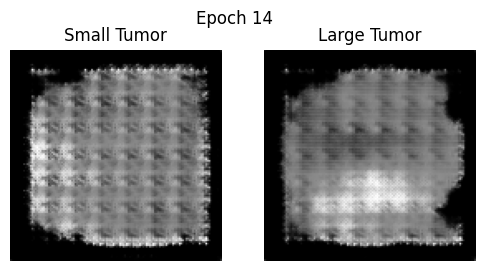

In [12]:
from tqdm import tqdm

EPOCHS = 14
PATIENCE = 10

best_g_loss = np.inf
wait = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    
    g_losses = []
    d_losses = []

    for img_batch, lab_batch in tqdm(dataset):
        g_loss, d_loss = train_step(img_batch, lab_batch)

        g_losses.append(g_loss.numpy())
        d_losses.append(d_loss.numpy())

    avg_g = np.mean(g_losses)
    avg_d = np.mean(d_losses)
    
    clear_output(wait=True)

    print(f"G Loss: {avg_g:.4f} | D Loss: {avg_d:.4f}")

    # 🔥 Early stopping
    if avg_g < best_g_loss:
        best_g_loss = avg_g
        wait = 0
        generator.save("best_generator.h5")
        print("✅ Best model saved")
    else:
        wait += 1
        print(f"No improvement: {wait}/{PATIENCE}")

        if wait >= PATIENCE:
            print("🛑 Early stopping triggered")
            break

    generate_images(epoch+1)

# Extra. Not Count

In [ ]:
TOTAL_IMAGES = 2000
BATCH_GEN = 32

all_images = []

steps = TOTAL_IMAGES // BATCH_GEN + int(TOTAL_IMAGES % BATCH_GEN != 0)

for step in range(steps):
    current_batch = min(BATCH_GEN, TOTAL_IMAGES - len(all_images)*BATCH_GEN)

    # -------------------------
    # Create balanced labels
    # -------------------------
    half = current_batch // 2
    labels = np.array([0]*half + [1]*(current_batch - half))
    np.random.shuffle(labels)

    labels_onehot = tf.one_hot(labels, depth=2)

    # -------------------------
    # Generate images
    # -------------------------
    noise = tf.random.normal([current_batch, z_dim])
    fake_images = generator([noise, labels_onehot], training=False)

    all_images.append(fake_images.numpy())

    print(f"Generated batch {step+1}/{steps}")

In [ ]:
generated_images = np.concatenate(all_images, axis=0)

print("Final shape:", generated_images.shape)

In [ ]:
np.save("generated_images_128.npy", generated_images)
print("✅ Saved successfully!")

In [ ]:
data = np.load("/kaggle/input/datasets/shantaakterid170/generated-cgan/generated_images_128 (8).npy")

print("Shape:", data.shape)
print("Min:", data.min(), "Max:", data.max())

# Extra. Not count. 

In [ ]:
indices = np.random.choice(len(data), 20, replace=False)

plt.figure(figsize=(10,8))

for i, idx in enumerate(indices):
    plt.subplot(4,5,i+1)
    
    img = data[idx].squeeze()
    img = (img + 1) / 2
    
    plt.imshow(img, cmap='gray')
    plt.axis('off')

plt.show()

# Generate 1000 small tumor and 1000 large tumor images

In [ ]:
TOTAL_IMAGES = 2000
BATCH_GEN = 32

all_images = []
all_labels = []   # ✅ ADD THIS

steps = TOTAL_IMAGES // BATCH_GEN + int(TOTAL_IMAGES % BATCH_GEN != 0)

generated_count = 0  # ✅ better tracking

for step in range(steps):
    current_batch = min(BATCH_GEN, TOTAL_IMAGES - generated_count)

    # -------------------------
    # Create balanced labels
    # -------------------------
    half = current_batch // 2
    labels = np.array([0]*half + [1]*(current_batch - half))
    np.random.shuffle(labels)

    labels_onehot = tf.one_hot(labels, depth=2)

    # -------------------------
    # Generate images
    # -------------------------
    noise = tf.random.normal([current_batch, z_dim])
    fake_images = generator([noise, labels_onehot], training=False)

    # ✅ STORE BOTH
    all_images.append(fake_images.numpy())
    all_labels.append(labels)

    generated_count += current_batch

    print(f"Generated batch {step+1}/{steps}")

# -------------------------
# Combine
# -------------------------
generated_images = np.concatenate(all_images, axis=0)
generated_labels = np.concatenate(all_labels, axis=0)

print("Images shape:", generated_images.shape)
print("Labels shape:", generated_labels.shape)

# -------------------------
# Save BOTH
# -------------------------
np.save("generated_images_128.npy", generated_images)
np.save("generated_labels.npy", generated_labels)

print("✅ Images + Labels saved successfully!")

# Generated images

In [ ]:
# new
import numpy as np
import matplotlib.pyplot as plt

# Load saved data
images = np.load("/kaggle/input/datasets/shantaakterid170/generated-cgan/generated_images_128 (8).npy")
labels = np.load("/kaggle/input/datasets/shantaakterid170/generated-cgan-label/generated_labels (2).npy")

plt.figure(figsize=(10,6))

for i in range(20):
    plt.subplot(4,5,i+1)

    # Get image and normalize
    img = images[i].squeeze()
    img = (img + 1) / 2   # [-1,1] → [0,1]

    # Get label text
    label_text = "Small Tumor" if labels[i] == 0 else "Large Tumor"

    plt.imshow(img, cmap='gray')
    plt.title(label_text, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Extra. Not count. early stages images

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load saved data
images = np.load("generated_images_128.npy")
labels = np.load("generated_labels.npy")

plt.figure(figsize=(10,8))

for i in range(20):
    plt.subplot(4,5,i+1)

    # Get image and normalize
    img = images[i].squeeze()
    img = (img + 1) / 2   # [-1,1] → [0,1]

    # Get label text
    label_text = "Small Tumor" if labels[i] == 0 else "Large Tumor"

    plt.imshow(img, cmap='gray')
    plt.title(label_text, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Set seed for reproducibility (optional)
np.random.seed(42)

# Randomly select 2000 indices
idx = np.random.choice(len(input_images), 2000, replace=False)

real_subset = input_images[idx]
fake_images=images[:2000]

print("Subset shape:", real_subset.shape)

In [ ]:
real_images = real_subset   # from your preprocessing code

# fake_images = np.load("/kaggle/working/generated_images_128.npy")

print("Real:", real_images.shape)
print("Fake:", fake_images.shape)

In [ ]:
print("Shape:", fake_images.shape)
print("Min:", fake_images.min(), "Max:", fake_images.max())

In [ ]:
print("Shape:", real_images.shape)
print("Min:", real_images.min(), "Max:", real_images.max())

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import preprocess_input

def preprocess_images(images):
    # assume images are in [-1,1]
    images = (images + 1.0) * 127.5
    
    # grayscale → RGB
    images = np.repeat(images, 3, axis=-1)
    
    # resize to 299x299
    images = tf.image.resize(images, (299, 299)).numpy()
    
    return preprocess_input(images)

real_proc = preprocess_images(real_images)
fake_proc = preprocess_images(fake_images)

In [ ]:
from tensorflow.keras.applications import InceptionV3

model = InceptionV3(include_top=False, pooling='avg', input_shape=(299,299,3))

In [ ]:
real_features = model.predict(real_proc, batch_size=32, verbose=1)
fake_features = model.predict(fake_proc, batch_size=32, verbose=1)

# FID score for best training.

In [ ]:
from scipy import linalg

def calculate_fid(f1, f2):
    mu1, sigma1 = f1.mean(axis=0), np.cov(f1, rowvar=False)
    mu2, sigma2 = f2.mean(axis=0), np.cov(f2, rowvar=False)

    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    return diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)

fid_score = calculate_fid(real_features, fake_features)
print("🎯 FID Score:", fid_score)

# Inital FID score .not great.

In [ ]:
from scipy import linalg

def calculate_fid(f1, f2):
    mu1, sigma1 = f1.mean(axis=0), np.cov(f1, rowvar=False)
    mu2, sigma2 = f2.mean(axis=0), np.cov(f2, rowvar=False)

    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    return diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)

fid_score = calculate_fid(real_features, fake_features)
print("🎯 FID Score:", fid_score)

# IS score

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import preprocess_input

def preprocess_images(images):
    # [-1,1] → [0,255]
    images = (images + 1.0) * 127.5
    
    # grayscale → RGB
    images = np.repeat(images, 3, axis=-1)
    
    # resize
    images = tf.image.resize(images, (299, 299)).numpy()
    
    return preprocess_input(images)

fake_proc = preprocess_images(fake_images)

In [ ]:
from tensorflow.keras.applications import InceptionV3

model = InceptionV3(include_top=True, weights='imagenet')

In [ ]:
preds = model.predict(fake_proc, batch_size=16, verbose=1)

In [ ]:
# new
import numpy as np
from scipy.stats import entropy

def calculate_inception_score(preds, splits=10):
    scores = []
    N = preds.shape[0]
    
    for i in range(splits):
        part = preds[i * N // splits : (i + 1) * N // splits]
        
        py = np.mean(part, axis=0)
        kl = part * (np.log(part + 1e-10) - np.log(py + 1e-10))
        kl_sum = np.mean(np.sum(kl, axis=1))
        
        scores.append(np.exp(kl_sum))
    
    return np.mean(scores), np.std(scores)

is_mean, is_std = calculate_inception_score(preds)

print(f"🎯 Inception Score: {is_mean:.4f} ± {is_std:.4f}")

In [ ]:
import numpy as np
from scipy.stats import entropy

def calculate_inception_score(preds, splits=10):
    scores = []
    N = preds.shape[0]
    
    for i in range(splits):
        part = preds[i * N // splits : (i + 1) * N // splits]
        
        py = np.mean(part, axis=0)
        kl = part * (np.log(part + 1e-10) - np.log(py + 1e-10))
        kl_sum = np.mean(np.sum(kl, axis=1))
        
        scores.append(np.exp(kl_sum))
    
    return np.mean(scores), np.std(scores)

is_mean, is_std = calculate_inception_score(preds)

print(f"🎯 Inception Score: {is_mean:.4f} ± {is_std:.4f}")

In [ ]:
# new
import matplotlib.pyplot as plt
import numpy as np

# Select 8 random images
idx_real = np.random.choice(len(real_images), 8, replace=False)
idx_fake = np.random.choice(len(fake_images), 8, replace=False)

real_sample = real_images[idx_real]
fake_sample = fake_images[idx_fake]

# Plot
plt.figure(figsize=(10, 8))

# -----------------------
# Real Images (Top Row)
# -----------------------
for i in range(8):
    plt.subplot(4, 4, i + 1)
    plt.imshow(real_sample[i].squeeze(), cmap='gray')
    plt.title("Real")
    plt.axis('off')

# -----------------------
# Fake Images (Bottom Row)
# -----------------------
for i in range(8):
    plt.subplot(4, 4, 8 + i + 1)
    plt.imshow(fake_sample[i].squeeze(), cmap='gray')
    plt.title("Fake")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Extra. Early stages

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Select 8 random images
idx_real = np.random.choice(len(real_images), 8, replace=False)
idx_fake = np.random.choice(len(fake_images), 8, replace=False)

real_sample = real_images[idx_real]
fake_sample = fake_images[idx_fake]

# Plot
plt.figure(figsize=(12, 6))

# -----------------------
# Real Images (Top Row)
# -----------------------
for i in range(8):
    plt.subplot(2, 8, i + 1)
    plt.imshow(real_sample[i].squeeze(), cmap='gray')
    plt.title("Real")
    plt.axis('off')

# -----------------------
# Fake Images (Bottom Row)
# -----------------------
for i in range(8):
    plt.subplot(2, 8, 8 + i + 1)
    plt.imshow(fake_sample[i].squeeze(), cmap='gray')
    plt.title("Fake")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Some generated images

In [ ]:
# new
import matplotlib.pyplot as plt
import numpy as np

# Select 20 random fake images
idx = np.random.choice(len(fake_images), 20, replace=False)
samples = fake_images[idx]

# Optional: convert [-1,1] → [0,1] for better visualization
def denormalize(img):
    return (img + 1) / 2

# Plot (4 rows × 5 columns)
plt.figure(figsize=(8,6))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(denormalize(samples[i]).squeeze(), cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# new
import matplotlib.pyplot as plt
import numpy as np

# Select 20 random fake images
idx = np.random.choice(len(fake_images), 20, replace=False)
samples = fake_images[idx]

# Optional: convert [-1,1] → [0,1] for better visualization
def denormalize(img):
    return (img + 1) / 2

# Plot (4 rows × 5 columns)
plt.figure(figsize=(10,6))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(denormalize(samples[i]).squeeze(), cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# new
import matplotlib.pyplot as plt
import numpy as np

# Select 20 random fake images
idx = np.random.choice(len(fake_images), 20, replace=False)
samples = fake_images[idx]

# Optional: convert [-1,1] → [0,1] for better visualization
def denormalize(img):
    return (img + 1) / 2

# Plot (4 rows × 5 columns)
plt.figure(figsize=(10,6))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(denormalize(samples[i]).squeeze(), cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

# Extra. Early stages images

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Select 20 random fake images
idx = np.random.choice(len(fake_images), 20, replace=False)
samples = fake_images[idx]

# Optional: convert [-1,1] → [0,1] for better visualization
def denormalize(img):
    return (img + 1) / 2

# Plot (4 rows × 5 columns)
plt.figure(figsize=(10, 6))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(denormalize(samples[i]).squeeze(), cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

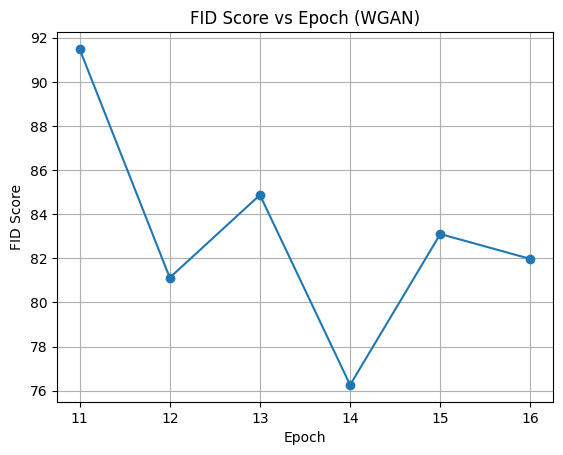

In [1]:
import matplotlib.pyplot as plt

# Data
epochs = [11, 12, 13, 14, 15, 16]
fid_scores = [91.49, 81.12, 84.87, 76.26, 83.10, 81.97]

# Plot
plt.figure()
plt.plot(epochs, fid_scores, marker='o')

plt.xlabel("Epoch")
plt.ylabel("FID Score")
plt.title("FID Score vs Epoch (WGAN)")

plt.grid()
plt.show()

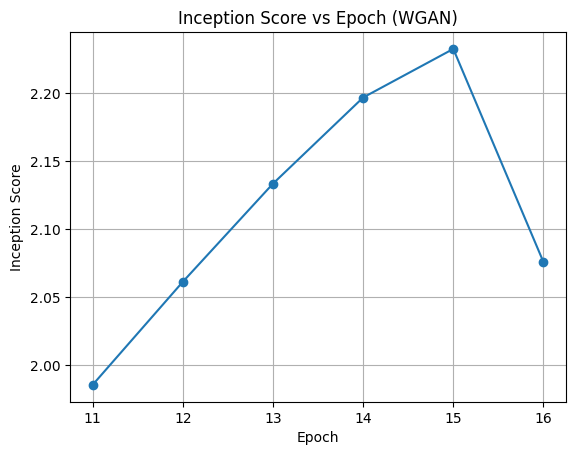

In [2]:
import matplotlib.pyplot as plt

# Data
epochs = [11, 12, 13, 14, 15, 16]
is_scores = [1.9856, 2.0613, 2.1334, 2.1967, 2.2324, 2.0758]

# Plot
plt.figure()
plt.plot(epochs, is_scores, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Inception Score")
plt.title("Inception Score vs Epoch (WGAN)")

plt.grid()
plt.show()

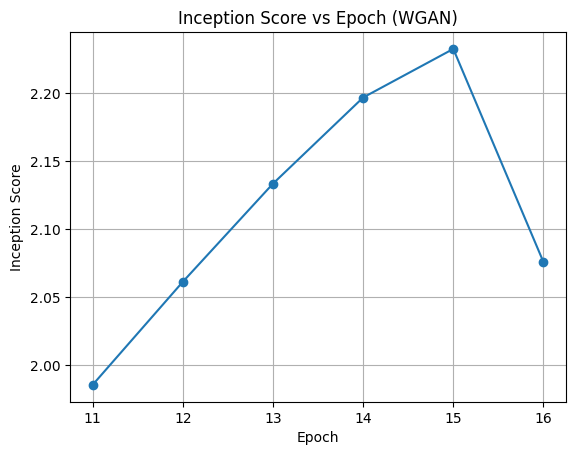

In [3]:
import matplotlib.pyplot as plt

# Data
epochs = [11, 12, 13, 14, 15, 16]
is_scores = [1.9856, 2.0613, 2.1334, 2.1967, 2.2324, 2.0758]

# Plot
plt.figure()
plt.plot(epochs, is_scores, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Inception Score")
plt.title("Inception Score vs Epoch (WGAN)")

plt.grid()
plt.show()

In [4]:
plt.savefig("fid_vs_epoch.png")
plt.savefig("is_vs_epoch.png")

<Figure size 640x480 with 0 Axes>

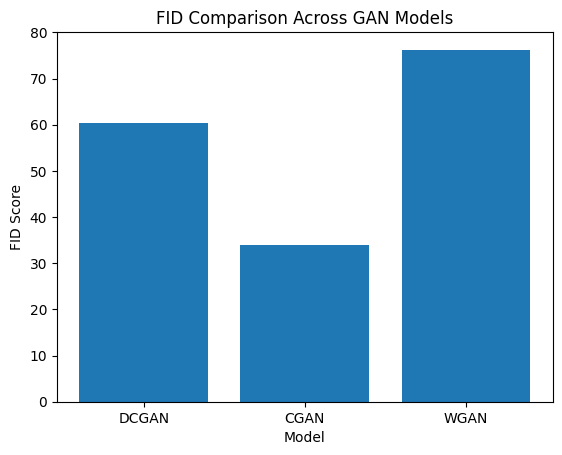

In [5]:
import matplotlib.pyplot as plt

models = ["DCGAN", "CGAN", "WGAN"]
fid_scores = [60.49, 34.06, 76.26]

plt.figure()
plt.bar(models, fid_scores)

plt.xlabel("Model")
plt.ylabel("FID Score")
plt.title("FID Comparison Across GAN Models")

plt.show()

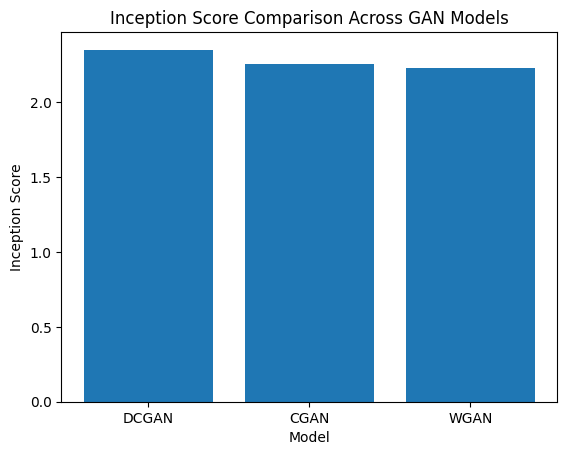

In [6]:
import matplotlib.pyplot as plt

models = ["DCGAN", "CGAN", "WGAN"]
is_scores = [2.3527, 2.2573, 2.2324]

plt.figure()
plt.bar(models, is_scores)

plt.xlabel("Model")
plt.ylabel("Inception Score")
plt.title("Inception Score Comparison Across GAN Models")

plt.show()